# Aprendizaje Profundo
## Tarea 2: Redes convolucionales y transferencia
### Eduardo García Alarcón - PCIC
#### Ejercicio 3 - Reconocimiento Comandos de Voz

Compara modelos basados en redes recurrentes y convolucionales para el reconocimiento de comandos de voz usando el conjunto de Speech Commands. En particular deberás:

- Entrenar y evaluar un modelo basado en capas convolucionales 1D
- Entrenar y evaluar un modelo basado en capas convolucionales 2D
- Graficar las pérdidas y métricas de entrenamiento y validación y discutir todos los resultados

En todos los casos, se deberán representar los comandos de voz mediante espectogramas Mel, Mel-log o MFCCs.

In [10]:
# Bibliotecas 図書館
import numpy as np
# import matplotlib
from matplotlib import pyplot as plt
from tqdm import tqdm, trange
import pandas as pd

import torch as th
from torch import nn

# Por reproducibilidad
th.manual_seed(42)
np.random.seed(42)

LOGDIR = './logs/'
DC     = 'cuda:0' if th.cuda.is_available() else 'cpu'
print(f'Device {DC}')

Device cuda:0


In [ ]:
# audio
import librosa
import librosa.display

# redes audio
import torchaudio
import torchaudio.transforms as T


# redes neuronales
from torch.utils.data import DataLoader
from torchaudio.datasets import SPEECHCOMMANDS

# barras de progreso
from tqdm.auto import trange

# Files
import os

In [2]:
DATADIR = './'

In [3]:
download = os.path.isdir('./SpeechCommands')
ds = SPEECHCOMMANDS(DATADIR, download=download)

### Escuchamos un ejemplo

In [4]:
waveform, sample_rate, label, id_spk, utt = ds[3078]

print(
    f'Etiqueta: {label}\n'
    f'Forma de onda: {waveform.shape}\n'
    f'Frecuencia de muestreo: {sample_rate}\n'
    f'Duración: {waveform.shape[1] / sample_rate}\n'
    f'Tipo: {waveform.dtype}\n'
)

Etiqueta: bed
Forma de onda: torch.Size([1, 14861])
Frecuencia de muestreo: 16000
Duración: 0.9288125
Tipo: torch.float32



## Por alguna razón el server donde corrí las cosas supongo que tuvo un conflicto entre _librosa_ y _matplotlib_, ya que no me dejó mostrar bien las gráficas.

Inclusive cuando intento graficar los resultados del accuracy en los modelos de abajo, imprime la onda de sonido solamente. Por eso es que no hay gráficas en algunos lados. Pero por lo menos tengo los print del entrenamiento. 

In [12]:
librosa.display.waveshow(waveform.flatten().numpy(), sr=sample_rate)

#### Hyper parámetros
Definimos el tamaño de ventana de la FFT, que es la resolución frecuencial

Y el tamaño de sobrelape que tiene nuetra ventana de muestreo; en este caso vamos a querer que sea un traslape de la mitad de la ventana

#### Se usarán los MFCCs para esta tarea

In [8]:
MFCC = T.MFCC()

/home/ar/.local/lib/python3.8/site-packages/torchaudio/functional/functional.py:571: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (128) may be set too high. Or, the value for `n_freqs` (201) may be set too low.
  warnings.warn(


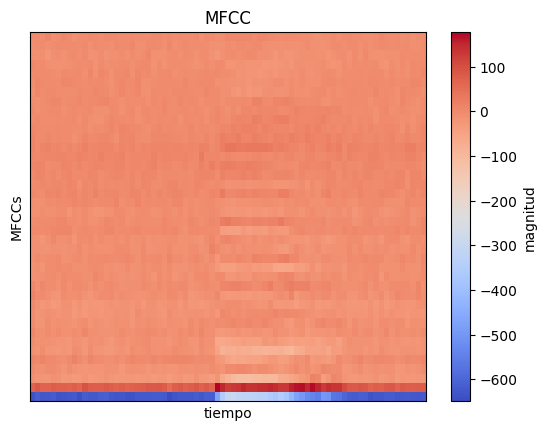

In [9]:
mfccs_numpy = MFCC(waveform).squeeze().numpy()

librosa.display.specshow(mfccs_numpy, sr=sample_rate, hop_length=hop_length)
plt.title('MFCC')
plt.xlabel('tiempo')
plt.ylabel('MFCCs')
cbar = plt.colorbar()
cbar.set_label('magnitud', rotation=90)
plt.show()

### Conjunto de datos

In [14]:
# Tamaño de lote
BATCH_SIZE = 64

# Audio Params
SECS = 1
SAMPLE_RATE = 16000

# FFT Params
N_FFT = 400
HOP_LENGHT = N_FFT//2

# SpeechCommands classes
CLASSES = (
    'backward', 'bed', 'bird', 'cat', 'dog',
    'down', 'eight', 'five', 'follow', 'forward',
    'four', 'go', 'happy', 'house', 'learn',
    'left', 'marvin', 'nine', 'no', 'off',
    'on', 'one', 'right', 'seven', 'sheila',
    'six', 'stop', 'three', 'tree', 'two',
    'up', 'visual', 'wow', 'yes', 'zero'
)

NUM_CLASSES = len(CLASSES)
CLASS_IDX = {c: i for i, c in enumerate(CLASSES)}
print(CLASS_IDX)

{'backward': 0, 'bed': 1, 'bird': 2, 'cat': 3, 'dog': 4, 'down': 5, 'eight': 6, 'five': 7, 'follow': 8, 'forward': 9, 'four': 10, 'go': 11, 'happy': 12, 'house': 13, 'learn': 14, 'left': 15, 'marvin': 16, 'nine': 17, 'no': 18, 'off': 19, 'on': 20, 'one': 21, 'right': 22, 'seven': 23, 'sheila': 24, 'six': 25, 'stop': 26, 'three': 27, 'tree': 28, 'two': 29, 'up': 30, 'visual': 31, 'wow': 32, 'yes': 33, 'zero': 34}


### Aumento de datos

In [15]:

def identity(x):
  return x


def label2index(label):
  return CLASS_IDX[label]


class SPEECHCOMMANDS2(SPEECHCOMMANDS):

  def __init__(self, root, download=False, subset=None,
               waveform_tsfm=identity, label_tsfm=identity):
      
      super().__init__(root=root, download=download, subset=subset)
      self.time_mask = T.TimeMasking(time_mask_param=4000)
      self.waveform_tsfm = waveform_tsfm
      self.label_tsfm = label_tsfm
      
  def __getitem__(self, i):
    waveform, sample_rate, label, *_ = super().__getitem__(i)

    x = self.waveform_tsfm(waveform)
    y = self.label_tsfm(label)
    return x, y, label, sample_rate

In [16]:
class WaveformPadTruncate(nn.Module):

  def __init__(self, secs=SECS, sample_rate=SAMPLE_RATE):
    super().__init__()
    self.samples = secs * sample_rate

  def forward(self, waveform):
    samples = waveform.shape[1]

    if samples < self.samples:
      difference = self.samples - samples
      padding = th.zeros(1, difference)
      waveform = th.cat([waveform, padding], 1)

    elif samples > self.samples:
      start = np.random.randint(0, waveform.shape[1] - self.samples)
      # Devuelve un nuevo tensor que es una versión reducida del tensor de entrada.
      waveform = waveform.narrow(1, start, self.samples) # (dimension, start, length)

    return waveform


In [17]:
from sklearn.model_selection import train_test_split

In [41]:
data_aug = nn.Sequential(
  WaveformPadTruncate(),
  # T.MelSpectrogram(n_fft=N_FFT, hop_length=HOP_LENGHT)
  T.MFCC(50)
)

In [42]:
# creamos un Dataset
ds = SPEECHCOMMANDS2(
    # directorio de datos
    root=DATADIR,
    # transformación de la forma de onda
    waveform_tsfm=data_aug,
    #conjunto de entrenamiento
    subset="training",
    # transformación de etiqueta
    label_tsfm=label2index,
)

# creamos un DataLoader
dl_ent = DataLoader(
    # conjunto
    ds,
    # tamaño del lote
    batch_size=BATCH_SIZE,
    # desordenar
    shuffle=True)


# creamos un Dataset
ds_val = SPEECHCOMMANDS2(
    root=DATADIR,
    # transformación de la forma de onda
    waveform_tsfm=data_aug,
    #conjunto de validacion
    subset="validation",
    # transformación de etiqueta
    label_tsfm=label2index,
)

# creamos un DataLoader
dl_val = DataLoader(
    # conjunto
    ds,
    # tamaño del lote
    batch_size=BATCH_SIZE,
    # desordenar
    shuffle=True)

In [43]:
# desplegamos un lote de ejemplos
x, y, labels, sr = next(iter(dl_ent))
print(f'x shape={x.shape} dtype={x.dtype}')
print(f'y shape={y.shape} dtype={y.dtype}')
print(f'{labels = }, {sr=}')

x shape=torch.Size([64, 1, 40, 81]) dtype=torch.float32
y shape=torch.Size([64]) dtype=torch.int64
labels = ('no', 'five', 'zero', 'off', 'yes', 'four', 'eight', 'left', 'zero', 'nine', 'down', 'seven', 'bird', 'bird', 'down', 'on', 'visual', 'up', 'left', 'stop', 'dog', 'stop', 'left', 'go', 'happy', 'go', 'eight', 'left', 'left', 'off', 'zero', 'down', 'up', 'right', 'zero', 'right', 'on', 'right', 'three', 'five', 'seven', 'right', 'nine', 'go', 'marvin', 'right', 'on', 'nine', 'dog', 'bed', 'wow', 'five', 'forward', 'yes', 'five', 'bird', 'zero', 'zero', 'six', 'dog', 'stop', 'zero', 'yes', 'on'), sr=tensor([16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000,
        16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000,
        16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000,
        16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000,
        16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000

In [44]:
# desplegamos un lote de ejemplos
x, y, labels, sr = next(iter(dl_val))
print(f'x shape={x.shape} dtype={x.dtype}')
print(f'y shape={y.shape} dtype={y.dtype}')
print(f'{labels = }, {sr=}')

x shape=torch.Size([64, 1, 40, 81]) dtype=torch.float32
y shape=torch.Size([64]) dtype=torch.int64
labels = ('no', 'down', 'wow', 'marvin', 'visual', 'nine', 'right', 'eight', 'yes', 'down', 'bird', 'on', 'nine', 'three', 'go', 'happy', 'dog', 'down', 'bed', 'three', 'right', 'go', 'sheila', 'yes', 'six', 'zero', 'three', 'three', 'visual', 'nine', 'bed', 'left', 'seven', 'stop', 'learn', 'three', 'no', 'down', 'forward', 'yes', 'one', 'seven', 'tree', 'forward', 'five', 'one', 'on', 'right', 'right', 'wow', 'cat', 'bird', 'no', 'four', 'up', 'eight', 'two', 'seven', 'six', 'cat', 'two', 'two', 'stop', 'down'), sr=tensor([16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000,
        16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000,
        16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000,
        16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000,
        16000, 16000, 16000, 16000, 16000, 16000, 16000, 16000, 16

### Redes Neuronales

#### Función de entrenamiento

In [45]:
import copy

def entrena_1d(modelo,
            fp,
            metrica,
            opt,
            entdl,
            valdl,
            disp,
            ckptpath,
            n_epocas = 10,
            tbdir = 'runs/'):
  n_lotes_ent = len(entdl)
  n_lotes_val = len(valdl)

  hist = {'perdida_ent':np.zeros(n_epocas),
          'perdida_val': np.zeros(n_epocas),
          metrica.__name__ + '_ent': np.zeros(n_epocas),
          metrica.__name__ + '_val': np.zeros(n_epocas)}

  tbwriter = SummaryWriter(tbdir)
  perdida_min = th.inf
  mejor_modelo = copy.deepcopy(modelo)

  for e in trange(n_epocas):
    # bucle de entrenamiento
    modelo.train()
    for p, (Xlote,ylote,_,_) in enumerate(entdl):
      
      Xlote = Xlote.to(disp)
      ylote = ylote.to(disp)
      #Formateamos las dimensiones de Xlote
      Xlote = Xlote.reshape(Xlote.size(0), 1, -1)  
        
      perdida_paso, metrica_paso = paso_ent(modelo,
                                            fp,
                                            metrica,
                                            opt,
                                            Xlote,
                                            ylote)

      hist['perdida_ent'][e] += perdida_paso
      hist[metrica.__name__ + '_ent'][e] += metrica_paso

    # bucle de validación
    modelo.eval()
    with th.no_grad():
      for Xlote,ylote,_,_ in valdl:
        
        Xlote = Xlote.to(disp)
        ylote = ylote.to(disp).long()
          
        # Cambio de foramto
        Xlote = Xlote.reshape(Xlote.size(0), 1, -1)    
        y_hat = modelo(Xlote)

        hist['perdida_val'][e] += fp(y_hat, ylote)
        hist[metrica.__name__ + '_val'][e] += metrica(y_hat, ylote)

    hist['perdida_ent'][e] /=  n_lotes_ent
    hist[metrica.__name__ + '_ent'][e] /= n_lotes_ent
    hist['perdida_val'][e] /=  n_lotes_val
    hist[metrica.__name__ + '_val'][e] /= n_lotes_val

    # guardamos checkpoint y copiamos pesos y sesgos del modelo
    # actual si disminuye la metrica a monitorear
    if hist['perdida_val'][e] < perdida_min:
      mejor_modelo.load_state_dict(modelo.state_dict())
      guarda_ckpt(ckptpath, modelo, e, opt)
      perdida_min = hist['perdida_val'][e]

    registra_info_tboard(tbwriter, e, hist)

    print(f'\nÉpoca {e}: '
          f'Perdida(E) = {hist["perdida_ent"][e]:.3f}, '
          f'{metrica.__name__}(E) = {hist[metrica.__name__ + "_ent"][e]:.3f}, '
          f'Perdida(V) = {hist["perdida_val"][e]:.3f}, '
          f'{metrica.__name__}(V) = {hist[metrica.__name__ + "_val"][e]:.3f}')

  return modelo, mejor_modelo, hist
######
from torch.utils.tensorboard import SummaryWriter
import torch as th

def registra_info_tboard(writer, epoca, hist):
  for (m,v) in hist.items():
    writer.add_scalar(m, v[epoca], epoca)

def guarda_ckpt(ckptpath, modelo, epoca, opt):
  estado_modelo = {'epoch': epoca,
                   'model_state_dict': modelo.state_dict(),
                   'optimizer_state_dict': opt.state_dict()}
  th.save(estado_modelo, ckptpath)
######
def exactitud(y_hat, y):
  cmp = y_hat.argmax(dim=-1) == y
  aciertos = th.count_nonzero(cmp)
  return aciertos / cmp.shape[0]

######
def paso_ent(modelo,
             fp,
             metrica,
             opt,
             X,
             y):
  opt.zero_grad() # se ponen los gradientes asociados a los parámetros
                    # a actualizaren en cero
  y_hat = modelo(X) # se propagan las entradas para obtener las predicciones
  perdida = fp(y_hat, y) # se calcula la pérdida
  perdida.backward() # se obtienen los gradientes
  opt.step() # se actualizan todos los parámetros del modelo

  with th.no_grad():
    perdida_paso = perdida.cpu().numpy() # convertimos la pérdida (instancia de
                                         # Tensor de orden 0) a NumPy, para
                                         # lo que es necesario moverla a CPU
    metricas_paso = metrica(y_hat, y)

  return perdida_paso, metricas_paso

#######

#### Red 1D

In [58]:
class Red1D(nn.Module):
  def __init__(self,  input_size, num_clases, sr=16000):
    super(Red1D, self).__init__()
    self.input_size = input_size
    self.num_clases = num_clases
    self.sr = sr
    # self.name = 'Red1D'
    
    self.conv1 = nn.Conv1d(input_size, 20, 3)
    self.maxPool = nn.MaxPool1d(4)
    self.conv2 = nn.Conv1d(20, 4, 3)
    self.globAvgPool = nn.MaxPool1d(1)
    self.fc = nn.Linear(4*201, num_clases)

  def forward(self, x):
    # print(f'{x.shape=}')
    # x = self.data_aug(x)
    x = self.conv1(x)
    # print(f'conv1 {x.shape=}')
    x = self.maxPool(x)
    # print(f'maxPool {x.shape=}')
    x = self.conv2(x)
    # print(f'conv2 {x.shape=}')
    x = self.maxPool(x)
    # print(f'maxPool{x.shape=}')
    x = self.globAvgPool(x)
    # print(f'globalAvg{x.shape=}')
    x = nn.functional.relu(x)
    # print(f'relu {x.shape=}')
    x = x.view(-1,4*201)
    # print(f'view {x.shape=}')
    x = self.fc(x)
    return x


In [59]:
# Entrenamos
modelo = Red1D(input_size=1, num_clases=NUM_CLASSES, sr=SAMPLE_RATE)
modelo.to(DC)

LOGDIR = './logs/'

perdida = nn.CrossEntropyLoss(weight=None,
                              reduction='mean')

opt = th.optim.Adam(modelo.parameters(),
                    lr=0.001)

modelo, mejor_modelo, hist = entrena_1d(modelo,
                                     perdida,
                                     exactitud,
                                     opt,
                                     dl_ent,
                                     dl_val,
                                     DC,
                                     LOGDIR+'red1.pt',
                                     n_epocas=10,
                                     tbdir=LOGDIR)

  0%|          | 0/10 [00:00<?, ?it/s]


Época 0: Perdida(E) = 2.341, exactitud(E) = 0.408, Perdida(V) = 1.603, exactitud(V) = 0.556

Época 1: Perdida(E) = 1.604, exactitud(E) = 0.556, Perdida(V) = 1.454, exactitud(V) = 0.598

Época 2: Perdida(E) = 1.478, exactitud(E) = 0.590, Perdida(V) = 1.384, exactitud(V) = 0.611

Época 3: Perdida(E) = 1.413, exactitud(E) = 0.608, Perdida(V) = 1.306, exactitud(V) = 0.637

Época 4: Perdida(E) = 1.372, exactitud(E) = 0.618, Perdida(V) = 1.289, exactitud(V) = 0.642

Época 5: Perdida(E) = 1.347, exactitud(E) = 0.623, Perdida(V) = 1.257, exactitud(V) = 0.651

Época 6: Perdida(E) = 1.325, exactitud(E) = 0.630, Perdida(V) = 1.268, exactitud(V) = 0.646

Época 7: Perdida(E) = 1.306, exactitud(E) = 0.634, Perdida(V) = 1.217, exactitud(V) = 0.660

Época 8: Perdida(E) = 1.296, exactitud(E) = 0.638, Perdida(V) = 1.197, exactitud(V) = 0.667

Época 9: Perdida(E) = 1.282, exactitud(E) = 0.642, Perdida(V) = 1.228, exactitud(V) = 0.656


AttributeError: module 'matplotlib' has no attribute 'axes'

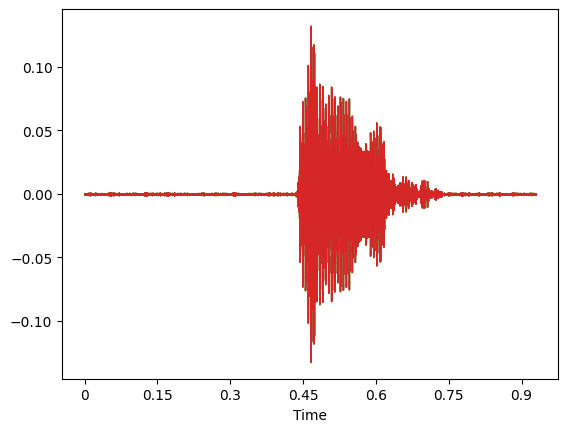

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

AttributeError: module 'matplotlib' has no attribute 'pyplot'

In [61]:
f,axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

axs[0].plot(hist['perdida_ent'], label='Entrenamiento')
axs[0].plot(hist['perdida_val'], label='Validación')
axs[0].set_xlabel('Época')
axs[0].set_ylabel('Pérdida')
axs[0].legend()

axs[1].plot(hist['exactitud_ent'], label='Entrenamiento')
axs[1].plot(hist['exactitud_val'], label='Validación')
axs[1].set_xlabel('Época')
axs[1].set_ylabel('Exactitud')
axs[1].legend()
plt.show()

### Red 2D

In [110]:
import copy

def entrena(modelo,
            fp,
            metrica,
            opt,
            entdl,
            valdl,
            disp,
            ckptpath,
            n_epocas = 10,
            tbdir = 'runs/'):
  n_lotes_ent = len(entdl)
  n_lotes_val = len(valdl)

  hist = {'perdida_ent':np.zeros(n_epocas),
          'perdida_val': np.zeros(n_epocas),
          metrica.__name__ + '_ent': np.zeros(n_epocas),
          metrica.__name__ + '_val': np.zeros(n_epocas)}

  tbwriter = SummaryWriter(tbdir)
  perdida_min = th.inf
  mejor_modelo = copy.deepcopy(modelo)

  for e in trange(n_epocas):
    # bucle de entrenamiento
    modelo.train()
    for p, (Xlote,ylote, _, __) in enumerate(entdl):
      Xlote = Xlote.to(disp)
      ylote = ylote.to(disp)

      perdida_paso, metrica_paso = paso_ent(modelo,
                                            fp,
                                            metrica,
                                            opt,
                                            Xlote,
                                            ylote)

      hist['perdida_ent'][e] += perdida_paso
      hist[metrica.__name__ + '_ent'][e] += metrica_paso

    # bucle de validación
    modelo.eval()
    with th.no_grad():
      for Xlote,ylote,_,__ in valdl:
        Xlote = Xlote.to(disp)
        ylote = ylote.to(disp)

        y_hat = modelo(Xlote)

        hist['perdida_val'][e] += fp(y_hat, ylote)
        hist[metrica.__name__ + '_val'][e] += metrica(y_hat, ylote)

    hist['perdida_ent'][e] /=  n_lotes_ent
    hist[metrica.__name__ + '_ent'][e] /= n_lotes_ent
    hist['perdida_val'][e] /=  n_lotes_val
    hist[metrica.__name__ + '_val'][e] /= n_lotes_val

    # guardamos checkpoint y copiamos pesos y sesgos del modelo
    # actual si disminuye la metrica a monitorear
    if hist['perdida_val'][e] < perdida_min:
      mejor_modelo.load_state_dict(modelo.state_dict())
      guarda_ckpt(ckptpath, modelo, e, opt)
      perdida_min = hist['perdida_val'][e]

    registra_info_tboard(tbwriter, e, hist)

    print(f'\nÉpoca {e}: '
          f'Perdida(E) = {hist["perdida_ent"][e]:.3f}, '
          f'{metrica.__name__}(E) = {hist[metrica.__name__ + "_ent"][e]:.3f}, '
          f'Perdida(V) = {hist["perdida_val"][e]:.3f}, '
          f'{metrica.__name__}(V) = {hist[metrica.__name__ + "_val"][e]:.3f}')

  return modelo, mejor_modelo, hist

In [108]:

class Red2D(nn.Module):
  def __init__(self,  input_size, num_clases, sr=16000):
    super(Red2D, self).__init__()
    self.input_size = input_size
    self.num_clases = num_clases
    self.sr = sr
    
    self.conv1 = nn.Conv2d(in_channels=input_size, out_channels=20, kernel_size=3, stride=1, padding=1)
    self.maxPool = nn.MaxPool2d((4,4))
    self.conv2 = nn.Conv2d(20, 4, 1)
    self.globAvgPool = nn.MaxPool2d((1,1))
    self.fc = nn.Linear(40, num_clases)

  def forward(self, x):
    # print(f'{x.shape=}')
    x = self.conv1(x)
    # print(f'conv1 {x.shape=}')
    x = self.maxPool(x)
    # print(f'maxPool {x.shape=}')
    x = self.conv2(x)
    # print(f'conv2 {x.shape=}')
    x = self.maxPool(x)
    # print(f'maxPool{x.shape=}')
    x = self.globAvgPool(x)
    # print(f'globalAvg{x.shape=}')
    x = x.flatten(start_dim=1)
    x = self.fc(x)
    return x


In [111]:
# Entrenamos
modelo = Red2D(input_size=1, num_clases=NUM_CLASSES, sr=SAMPLE_RATE)
modelo.to(DC)

LOGDIR = './logs/'

perdida = nn.CrossEntropyLoss(weight=None,
                              reduction='mean')

opt = th.optim.Adam(modelo.parameters(),
                    lr=0.001)

modelo, mejor_modelo, hist = entrena(modelo,
                                     perdida,
                                     exactitud,
                                     opt,
                                     dl_ent,
                                     dl_val,
                                     DC,
                                     LOGDIR+'red1.pt',
                                     n_epocas=10,
                                     tbdir=LOGDIR)

  0%|          | 0/10 [00:00<?, ?it/s]


Época 0: Perdida(E) = 3.815, exactitud(E) = 0.074, Perdida(V) = 3.133, exactitud(V) = 0.141

Época 1: Perdida(E) = 3.022, exactitud(E) = 0.169, Perdida(V) = 2.937, exactitud(V) = 0.190

Época 2: Perdida(E) = 2.888, exactitud(E) = 0.205, Perdida(V) = 2.832, exactitud(V) = 0.217

Época 3: Perdida(E) = 2.809, exactitud(E) = 0.224, Perdida(V) = 2.765, exactitud(V) = 0.233

Época 4: Perdida(E) = 2.766, exactitud(E) = 0.234, Perdida(V) = 2.733, exactitud(V) = 0.246

Época 5: Perdida(E) = 2.742, exactitud(E) = 0.242, Perdida(V) = 2.716, exactitud(V) = 0.248

Época 6: Perdida(E) = 2.725, exactitud(E) = 0.248, Perdida(V) = 2.707, exactitud(V) = 0.251

Época 7: Perdida(E) = 2.713, exactitud(E) = 0.250, Perdida(V) = 2.686, exactitud(V) = 0.257

Época 8: Perdida(E) = 2.703, exactitud(E) = 0.253, Perdida(V) = 2.684, exactitud(V) = 0.259

Época 9: Perdida(E) = 2.694, exactitud(E) = 0.256, Perdida(V) = 2.676, exactitud(V) = 0.260


## Conclusiones

Podemos observar que usando el mismo tipo de dato, que serían los MFCCs, las redes de una dimensión tuvieron mejor desempeño que las redes convolucionales de dos dimensiones por casi el doble.

En lo personal estaba pensando que las 2d serían mejores en la tarea, pero tal vez por la manera en la que son representados los MFCCs el cambio entre bin's es abrupto, por lo cual la red no puede diferenciar bien esas zonas.

O por otro lado tenemos que las señales de audio son series de tiempo, las cuales son mejores interpretadas cuando se analiza por el tiempo, en vez de sus componentes de frecuencia. Ya que podría suceder que dos señales tengan el mismo (o muy similar) comportamiento espectral. 